In [1]:
import os
from pathlib import Path
from PIL import Image
import numpy as np
import json
from typing import List, Dict


def load_daps_results(daps_results_dir="/media/embedded/Users/Nisim/MSc/AdvancedTopicImageandSP/final_project/DAPS/results/debluring_demo_celeb"):
    """
    Load images from DAPS results folder, selecting only the first run output for each image.
    
    The samples folder contains images named "xxxx_run000y.png" where x is the image ID and y is the run number.
    This function selects only run 0001 (first run) for each image.
    
    Args:
        daps_results_dir: Path to the DAPS results directory containing 'samples' subfolder
        
    Returns:
        List of PIL Image objects, sorted by image ID
    """
    samples_dir = Path(daps_results_dir) / "samples"
    
    if not samples_dir.exists():
        raise FileNotFoundError(f"Samples directory not found: {samples_dir}")
    
    # Find all images with run0001 (first run)
    images_dict = {}
    
    for img_file in sorted(samples_dir.glob("*_run0001.png")):
        # Extract image ID from filename (e.g., "0001_run0001.png" -> "0001")
        image_id = img_file.stem.split("_run")[0]
        
        try:
            img = Image.open(img_file)
            images_dict[image_id] = img
        except Exception as e:
            print(f"Error loading image {img_file}: {e}")
    
    # Return images sorted by ID
    sorted_images = [images_dict[key] for key in sorted(images_dict.keys())]
    
    print(f"Loaded {len(sorted_images)} images from DAPS results (first run only)")
    return sorted_images


def load_comparison_folder(folder_path: str) -> Dict[str, List]:
    """
    Load images from a comparison folder structure.
    
    The folder should contain subfolders: "inputs", "distorted", and "restored".
    Each subfolder contains images to be loaded.
    
    Args:
        folder_path: Path to the comparison folder containing the subfolders
        
    Returns:
        Dictionary with keys "inputs", "distorted", "restored" and lists of PIL Images as values
    """
    folder_path = Path(folder_path)
    
    if not folder_path.exists():
        raise FileNotFoundError(f"Folder not found: {folder_path}")
    
    subfolders = ["inputs", "distorted", "restored"]
    result = {}
    
    for subfolder_name in subfolders:
        subfolder = folder_path / subfolder_name
        
        if not subfolder.exists():
            print(f"Warning: Subfolder not found: {subfolder}")
            result[subfolder_name] = []
            continue
        
        images = []
        # Load all image files and sort them
        image_files = sorted([f for f in subfolder.glob("*") 
                            if f.suffix.lower() in ['.png', '.jpg', '.jpeg']])
        
        for img_file in image_files:
            try:
                img = Image.open(img_file)
                images.append(img)
            except Exception as e:
                print(f"Error loading image {img_file}: {e}")
        
        result[subfolder_name] = images
        print(f"Loaded {len(images)} images from {subfolder_name}")
    
    return result

In [2]:
exp_folder = "/media/embedded/Users/Nisim/MSc/AdvancedTopicImageandSP/final_project/shortcut_resample/shortcut-models/shortcut_restoration_results/closed_form_64dts_rho0.1_lr0.1_lat0.85_15optrnds_7"

In [3]:
# Example usage:

# Load DAPS results (first run only)
daps_images = load_daps_results()

# Load comparison folder
comparison_results = load_comparison_folder(exp_folder)
    
# Add DAPS images to the dictionary
comparison_results['daps'] = daps_images

# Access the images
print(f"Number of DAPS images: {len(comparison_results['daps'])}")
print(f"Number of inputs: {len(comparison_results['inputs'])}")
print(f"Number of distorted: {len(comparison_results['distorted'])}")
print(f"Number of restored: {len(comparison_results['restored'])}")

Loaded 10 images from DAPS results (first run only)
Loaded 10 images from inputs
Loaded 10 images from distorted
Loaded 10 images from restored
Number of DAPS images: 10
Number of inputs: 10
Number of distorted: 10
Number of restored: 10


In [4]:
def load_ours_results(results_dir: str):
    """
    Load CSV results from an "Ours" result folder.

    Expected: one summary CSV and one per-image details CSV.
    Returns a dict with parsed summary/details and discovered paths.
    """
    from pathlib import Path
    import csv

    folder = Path(results_dir)
    if not folder.exists():
        raise FileNotFoundError(f"Results folder not found: {folder}")

    csv_files = sorted(folder.glob("*.csv"))
    if len(csv_files) < 2:
        raise ValueError(f"Expected at least 2 CSV files in {folder}, found {len(csv_files)}")

    summary_candidates = [p for p in csv_files if "summary" in p.stem.lower()]
    details_candidates = [p for p in csv_files if any(k in p.stem.lower() for k in ["detail", "details", "per_image", "perimage"])]

    summary_path = summary_candidates[0] if summary_candidates else None
    details_path = details_candidates[0] if details_candidates else None

    if summary_path is None or details_path is None:
        row_counts = []
        for p in csv_files:
            with open(p, "r", newline="") as f:
                n_rows = sum(1 for _ in f) - 1
            row_counts.append((p, max(n_rows, 0)))

        row_counts.sort(key=lambda x: x[1])
        if summary_path is None:
            summary_path = row_counts[0][0]
        if details_path is None:
            for p, _ in reversed(row_counts):
                if p != summary_path:
                    details_path = p
                    break

    if summary_path is None or details_path is None:
        raise ValueError("Could not infer summary/details CSV files")

    try:
        import pandas as pd

        summary = pd.read_csv(summary_path)
        details = pd.read_csv(details_path)
        backend = "pandas"
        print(f"Loaded summary CSV: {summary_path} (shape={summary.shape})")
        print(f"Loaded details CSV: {details_path} (shape={details.shape})")
    except Exception:
        with open(summary_path, "r", newline="") as f:
            summary = list(csv.DictReader(f))
        with open(details_path, "r", newline="") as f:
            details = list(csv.DictReader(f))
        backend = "csv"
        print(f"Loaded summary CSV: {summary_path} (rows={len(summary)})")
        print(f"Loaded details CSV: {details_path} (rows={len(details)})")

    return {
        "summary_path": str(summary_path),
        "details_path": str(details_path),
        "summary": summary,
        "details": details,
        "backend": backend,
    }

In [5]:
# Load DAPS results using load_ours_results (DAPS now has same CSV format)
_daps_metrics = load_ours_results(
    "/media/embedded/Users/Nisim/MSc/AdvancedTopicImageandSP/final_project/shortcut_resample/shortcut-models/shortcut_restoration_results/DAPS_results_10_images"
)
print("DAPS from CSV - backend:", _daps_metrics["backend"])
print("DAPS from CSV - summary path:", _daps_metrics["summary_path"])
print("DAPS from CSV - details path:", _daps_metrics["details_path"])
if _daps_metrics["backend"] == "pandas":
    print("DAPS from CSV - summary columns:", list(_daps_metrics["summary"].columns))
    print("DAPS from CSV - details columns:", list(_daps_metrics["details"].columns))
    print("DAPS from CSV - details shape:", _daps_metrics["details"].shape)


Loaded summary CSV: /media/embedded/Users/Nisim/MSc/AdvancedTopicImageandSP/final_project/shortcut_resample/shortcut-models/shortcut_restoration_results/DAPS_results_10_images/summary.csv (shape=(1, 5))
Loaded details CSV: /media/embedded/Users/Nisim/MSc/AdvancedTopicImageandSP/final_project/shortcut_resample/shortcut-models/shortcut_restoration_results/DAPS_results_10_images/details.csv (shape=(10, 5))
DAPS from CSV - backend: pandas
DAPS from CSV - summary path: /media/embedded/Users/Nisim/MSc/AdvancedTopicImageandSP/final_project/shortcut_resample/shortcut-models/shortcut_restoration_results/DAPS_results_10_images/summary.csv
DAPS from CSV - details path: /media/embedded/Users/Nisim/MSc/AdvancedTopicImageandSP/final_project/shortcut_resample/shortcut-models/shortcut_restoration_results/DAPS_results_10_images/details.csv
DAPS from CSV - summary columns: ['num_images', 'avg_time', 'avg_lpips', 'avg_psnr', 'avg_ssim']
DAPS from CSV - details columns: ['image', 'time', 'lpips', 'psnr', 

In [6]:
# Validation for load_ours_results (fixed function cell)
_ours_results = load_ours_results(exp_folder)
    
print("backend:", _ours_results["backend"])
print("summary path:", _ours_results["summary_path"])
print("details path:", _ours_results["details_path"])
if _ours_results["backend"] == "pandas":
    print("summary columns:", list(_ours_results["summary"].columns))
    print("details columns:", list(_ours_results["details"].columns))
else:
    print("summary keys:", list(_ours_results["summary"][0].keys()) if _ours_results["summary"] else [])
    print("details keys:", list(_ours_results["details"][0].keys()) if _ours_results["details"] else [])

Loaded summary CSV: /media/embedded/Users/Nisim/MSc/AdvancedTopicImageandSP/final_project/shortcut_resample/shortcut-models/shortcut_restoration_results/closed_form_64dts_rho0.1_lr0.1_lat0.85_15optrnds_7/summary.csv (shape=(1, 5))
Loaded details CSV: /media/embedded/Users/Nisim/MSc/AdvancedTopicImageandSP/final_project/shortcut_resample/shortcut-models/shortcut_restoration_results/closed_form_64dts_rho0.1_lr0.1_lat0.85_15optrnds_7/details.csv (shape=(10, 5))
backend: pandas
summary path: /media/embedded/Users/Nisim/MSc/AdvancedTopicImageandSP/final_project/shortcut_resample/shortcut-models/shortcut_restoration_results/closed_form_64dts_rho0.1_lr0.1_lat0.85_15optrnds_7/summary.csv
details path: /media/embedded/Users/Nisim/MSc/AdvancedTopicImageandSP/final_project/shortcut_resample/shortcut-models/shortcut_restoration_results/closed_form_64dts_rho0.1_lr0.1_lat0.85_15optrnds_7/details.csv
summary columns: ['num_images', 'avg_time', 'avg_lpips', 'avg_psnr', 'avg_ssim']
details columns: ['i

# Summary:
I compared the DAPS to our current implementation.
The algorithm i used involves a mixed of pixel and latent GD opt of the MSE score.<br>

Initialize $z_t = {z_0}\sim N(0, 1)$, define the number of denoising step ${N_{ds}}$, the fraction of the way from which a latent opt is applied $thresh$<br>
For step ${t_i}$ in 0, ..., $N_{ds}$-1; do<br>

* Calc $t=\frac{t_i}{N_{ds}}$
* Predict v with $v=model(z_t, step)$
* Calculate $\hat{z}_1 = z_t + (1-t)\cdot v$
* if $t<thresh$ perform pixel opt for k1 steps to obtain z'_1
* else perform latent opt for k2 steps to obtain z'_1
* $z_{t_{+}} = t_{+}z'_1 + (1-t_{+})\varepsilon $

**********
### Pixel opt:
x_1 = decode($\hat{z_1}$)<br>
For step in 1, ..., k1
* $g = \nabla_{x_1}(\mathcal{A}\hat{x}_1-y)^2$
* $x_1 = x_1 - \gamma\cdot g$

Finaly:
* $z'_1 = \mathcal{E}(x'_t)$

**********
### Latent opt:
For step in 1, ..., k2
* x_1 = decode($\hat{z_1}$)<br>
* $g = \nabla_{z_1}(\mathcal{A}x_1-y)^2$
* $z_1 = z_1 - \gamma\cdot g$

Finally:
* $z'_1 = z_1$

## About runtime:
The DAPS algorithm is very slow, took about an hour for the 10 images in the test.<br>
The above implementation takes about 5 seconds per image when i used 32 shortcut steps.

## About the results:
Visually speaking, the results are not far apart. In some cases our are favorable though slight "halucinations" are observable.
Numerically speaking, DAPS outperforms us on average.

Need to think about ways to incorporate the features of shortcut into the pipeline.
I tried running a hierarchical approach where i used 2 steps procedure at the beggining then kick-started the restoration of a 4 steps procedure with the result of the former at 0.25 of the way and so on until 32 steps. No significant improvement. Need to go over it see if it can be improved.


In [7]:
import matplotlib.pyplot as plt


def draw_comparison(
    comparison_results: Dict[str, List],
    daps_results: Dict = None,
    ours_results: Dict = None,
    metric_names=("psnr", "ssim", "lpips"),
    max_rows: int = None,
):
    """
    Draw image comparison grid and annotate per-image metrics for DAPS and Ours.

    Columns are: Clean, Blured, DAPS, Ours.
    
    Both daps_results and ours_results should have the same format:
    dict with 'details' (DataFrame) and 'summary' (DataFrame) keys.
    """
    required_keys = ["inputs", "distorted", "daps", "restored"]
    for key in required_keys:
        if key not in comparison_results:
            raise KeyError(f"Missing key in comparison_results: {key}")

    num_rows = min(len(comparison_results[k]) for k in required_keys)

    # Adjust num_rows based on available metrics
    if daps_results is not None:
        daps_details = daps_results.get("details")
        if daps_details is not None and hasattr(daps_details, "shape"):
            num_rows = min(num_rows, int(daps_details.shape[0]))

    if ours_results is not None:
        ours_details = ours_results.get("details")
        if ours_details is not None and hasattr(ours_details, "shape"):
            num_rows = min(num_rows, int(ours_details.shape[0]))

    if max_rows is not None:
        num_rows = min(num_rows, max_rows)

    if num_rows <= 0:
        raise ValueError("No rows available to display")

    num_cols = 4
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 4 * num_rows))

    if num_rows == 1:
        axes = axes.reshape(1, -1)

    headers = ["Clean", "Blured", "DAPS", "Ours"]
    data_keys = ["inputs", "distorted", "daps", "restored"]

    for col_idx, header in enumerate(headers):
        axes[0, col_idx].text(
            0.5,
            1.12,
            header,
            transform=axes[0, col_idx].transAxes,
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
        )

    def _fmt_metric_line(results_dict: Dict, row_idx: int, prefix: str):
        """Format metric line from results dict with 'details' DataFrame."""
        if results_dict is None:
            return None
        details = results_dict.get("details")
        if details is None:
            return None
        if hasattr(details, "iloc"):
            if row_idx >= len(details):
                return None
            row = details.iloc[row_idx]
            parts = [prefix]
            for name in metric_names:
                if name in row.index:
                    try:
                        parts.append(f"{name.upper()}: {float(row[name]):.4f}")
                    except Exception:
                        parts.append(f"{name.upper()}: {row[name]}")
            return " | ".join(parts)
        return None

    for row_idx in range(num_rows):
        for col_idx, key in enumerate(data_keys):
            ax = axes[row_idx, col_idx]
            img = comparison_results[key][row_idx]
            ax.imshow(img)
            ax.axis("off")

            if col_idx == 0:
                ax.text(
                    -0.2,
                    0.5,
                    f"Image {row_idx + 1}",
                    transform=ax.transAxes,
                    ha="right",
                    va="center",
                    fontsize=10,
                    fontweight="bold",
                )

            if col_idx == 2:
                daps_line = _fmt_metric_line(daps_results, row_idx, "DAPS")
                if daps_line is not None:
                    ax.text(
                        0.02,
                        1.02,
                        daps_line,
                        transform=ax.transAxes,
                        fontsize=8,
                        ha="left",
                        va="bottom",
                        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
                    )

            if col_idx == 3:
                ours_line = _fmt_metric_line(ours_results, row_idx, "Ours")
                if ours_line is not None:
                    ax.text(
                        0.02,
                        1.02,
                        ours_line,
                        transform=ax.transAxes,
                        fontsize=8,
                        ha="left",
                        va="bottom",
                        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
                    )

    plt.tight_layout()
    return fig, axes



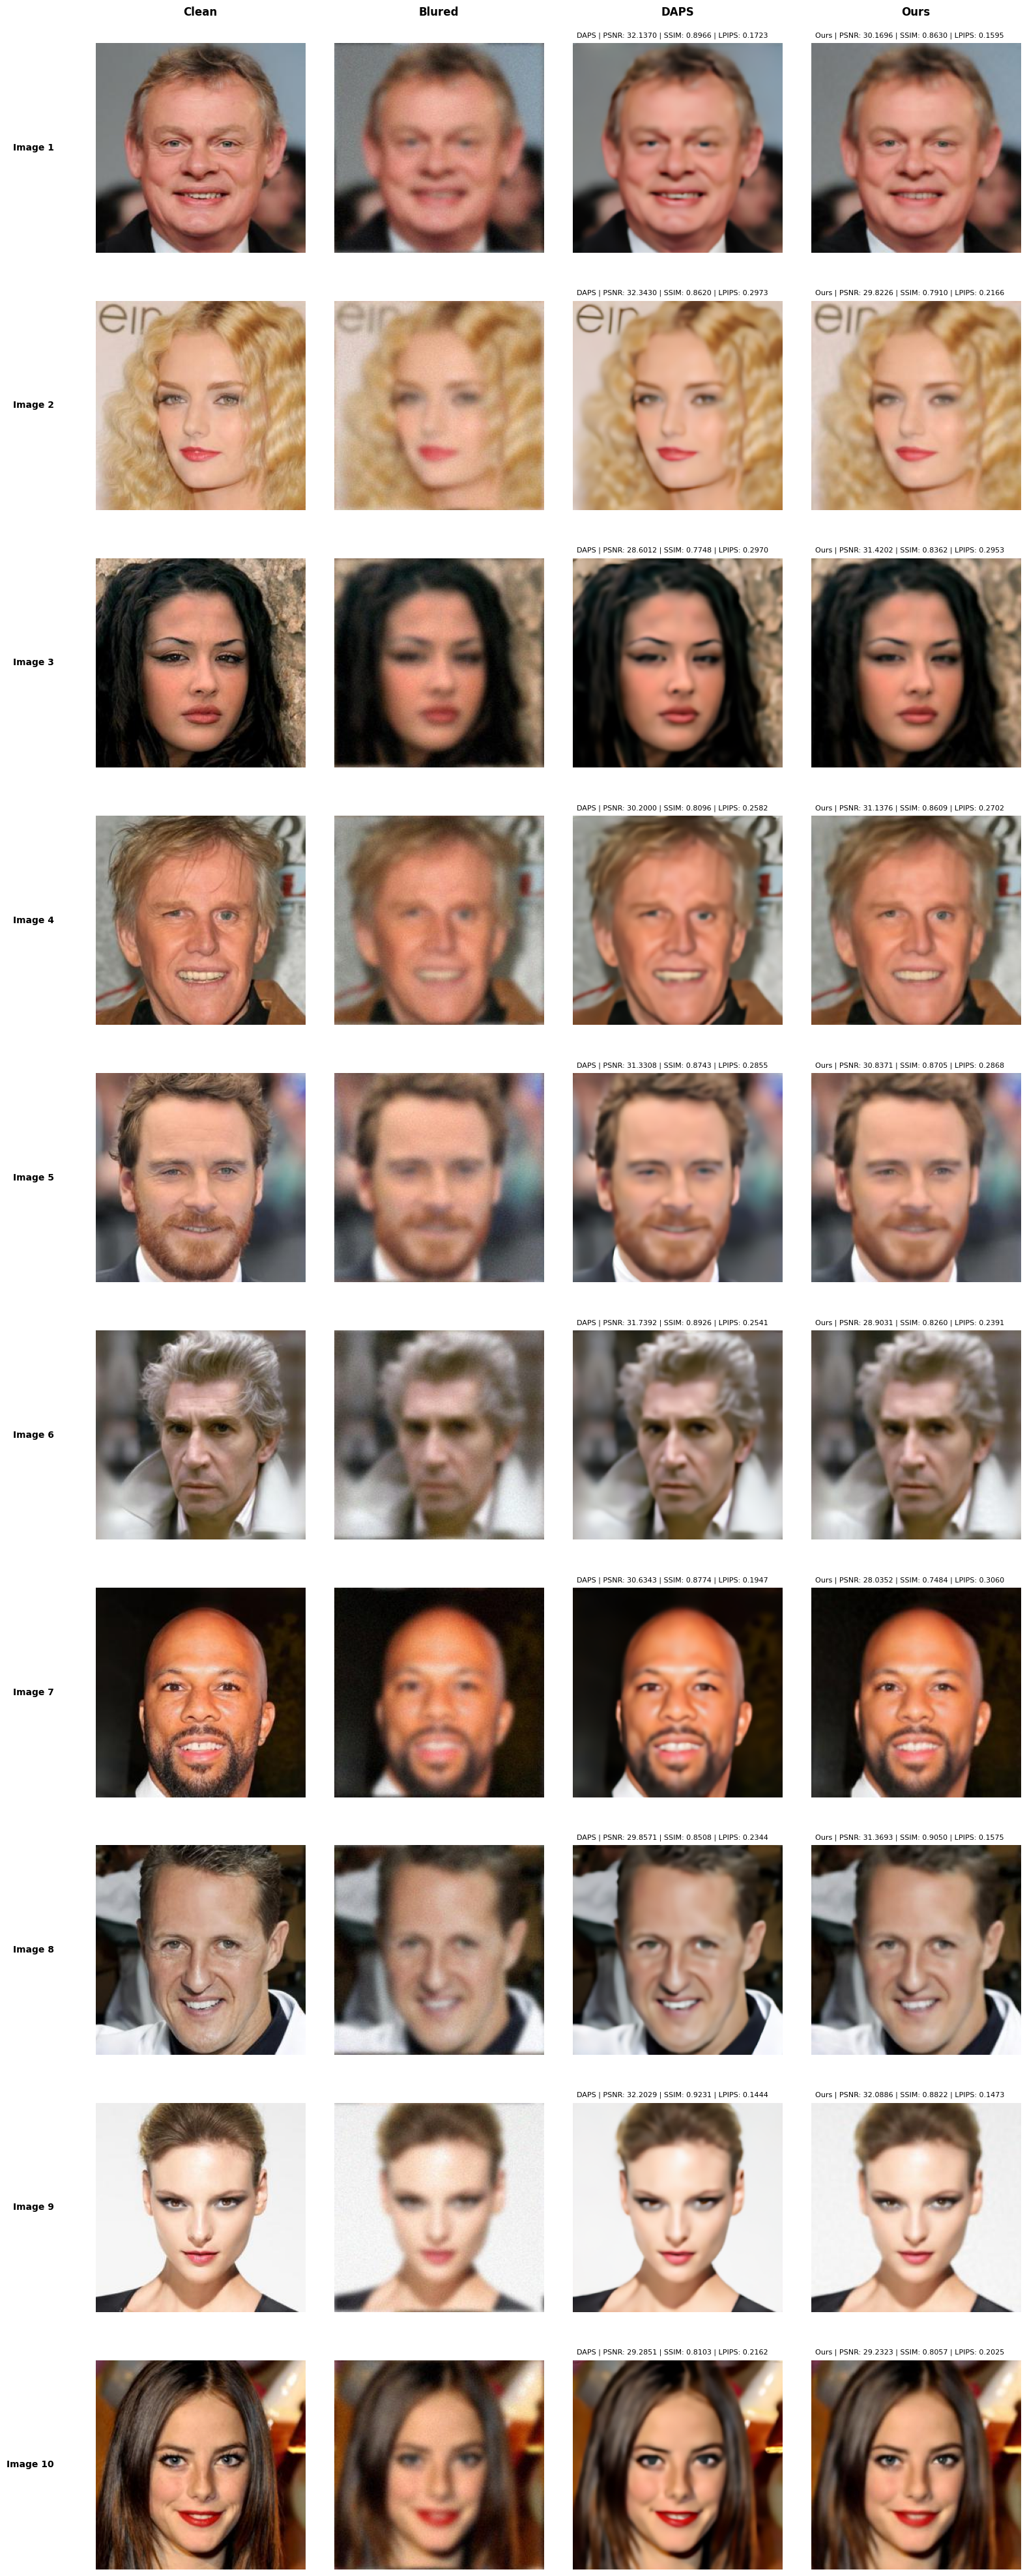

In [10]:
# Render comparison with per-image metrics from DAPS and Ours
fig, axes = draw_comparison(
    comparison_results=comparison_results,
    daps_results=_daps_metrics,
    ours_results=_ours_results,
)
plt.show()


In [9]:
import pandas as pd
from IPython.display import display, HTML

_metric_names = ("psnr", "ssim", "lpips")
_lower_is_better = {"lpips"}  # for these metrics, lower is better

# Extract details DataFrames
_daps_details = _daps_metrics.get("details") if _daps_metrics is not None else None
_ours_details = _ours_results.get("details") if _ours_results is not None else None

if _daps_details is None or _ours_details is None:
    print("Error: Missing details data")
else:
    num_images = min(len(_daps_details), len(_ours_details))
    
    # -- Per-image table (columns grouped by metric: PSNR DAPS, PSNR Ours, ...)
    rows = []
    for i in range(num_images):
        row = {"Image": i + 1}
        daps_row = _daps_details.iloc[i] if i < len(_daps_details) else None
        ours_row = _ours_details.iloc[i] if i < len(_ours_details) else None
        
        for m in _metric_names:
            row[f"{m.upper()} DAPS"] = round(float(daps_row[m]), 4) if (daps_row is not None and m in daps_row.index) else float("nan")
            row[f"{m.upper()} Ours"] = round(float(ours_row[m]), 4) if (ours_row is not None and m in ours_row.index) else float("nan")
        rows.append(row)
    
    per_image_df = pd.DataFrame(rows).set_index("Image")
    
    def _highlight_better(df):
        styles = pd.DataFrame("", index=df.index, columns=df.columns)
        for m in _metric_names:
            col_daps = f"{m.upper()} DAPS"
            col_ours = f"{m.upper()} Ours"
            if col_daps not in df.columns or col_ours not in df.columns:
                continue
            for idx in df.index:
                v_daps = df.at[idx, col_daps]
                v_ours = df.at[idx, col_ours]
                if pd.isna(v_daps) or pd.isna(v_ours):
                    continue
                daps_is_better = (v_daps < v_ours) if m.lower() in _lower_is_better else (v_daps > v_ours)
                if daps_is_better:
                    styles.at[idx, col_daps] = "font-weight: bold"
                else:
                    styles.at[idx, col_ours] = "font-weight: bold"
        return styles
    
    display(HTML("<h3>Per-Image Metrics</h3>"))
    display(per_image_df.style.apply(_highlight_better, axis=None))
    
    # -- Summary table (metrics as rows, methods as columns)
    summary_data = []
    
    # DAPS summary
    if _daps_metrics is not None:
        daps_summ = _daps_metrics.get("summary")
        if daps_summ is not None and hasattr(daps_summ, "iloc"):
            r = daps_summ.iloc[0]
            summary_data.append({
                "Method": "DAPS",
                **{m.upper(): round(float(r[f"avg_{m}"]), 4) if f"avg_{m}" in r.index else float("nan") for m in _metric_names},
            })
    
    # Ours summary
    if _ours_results is not None:
        ours_summ = _ours_results.get("summary")
        if ours_summ is not None and hasattr(ours_summ, "iloc"):
            r = ours_summ.iloc[0]
            summary_data.append({
                "Method": "Ours",
                **{m.upper(): round(float(r[f"avg_{m}"]), 4) if f"avg_{m}" in r.index else float("nan") for m in _metric_names},
            })
    
    summary_df = pd.DataFrame(summary_data).set_index("Method").T
    summary_df.index.name = "Metric"
    display(HTML("<h3>Summary (Averages)</h3>"))
    display(summary_df)



,PSNR DAPS,PSNR Ours,SSIM DAPS,SSIM Ours,LPIPS DAPS,LPIPS Ours
Image,,,,,,
1,32.137000,30.169600,0.896600,0.863000,0.172300,0.159500
2,32.343000,29.822600,0.862000,0.791000,0.297300,0.216600
3,28.601200,31.420200,0.774800,0.836200,0.297000,0.295300
4,30.200000,31.137600,0.809600,0.860900,0.258200,0.270200
5,31.330800,30.837100,0.874300,0.870500,0.285500,0.286800
6,31.739200,28.903100,0.892600,0.826000,0.254100,0.239100
7,30.634300,28.035200,0.877400,0.748400,0.194700,0.306000
8,29.857100,31.369300,0.850800,0.905000,0.234400,0.157500
9,32.202900,32.088600,0.923100,0.882200,0.144400,0.147300


Method,DAPS,Ours
Metric,,
PSNR,30.8331,30.3016
SSIM,0.8572,0.8389
LPIPS,0.2354,0.2281
